
Logistic Regression Model Performance:
Accuracy: 0.71
Precision: 0.71
Recall: 0.71
F1-Score: 0.71
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.70      0.69      1391
           1       0.73      0.72      0.73      1589

    accuracy                           0.71      2980
   macro avg       0.71      0.71      0.71      2980
weighted avg       0.71      0.71      0.71      2980



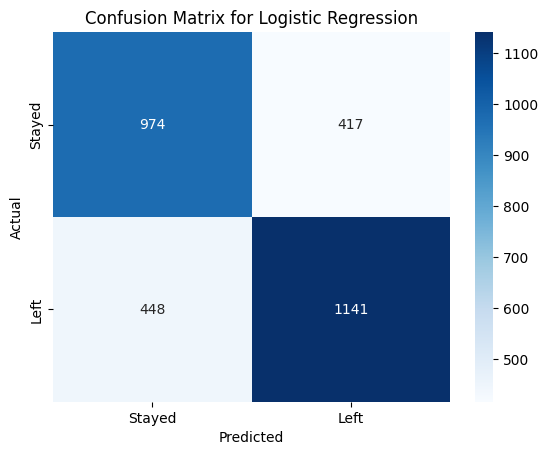


Decision Tree Model Performance:
Accuracy: 0.65
Precision: 0.65
Recall: 0.65
F1-Score: 0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.64      0.63      1391
           1       0.68      0.65      0.66      1589

    accuracy                           0.65      2980
   macro avg       0.65      0.65      0.65      2980
weighted avg       0.65      0.65      0.65      2980



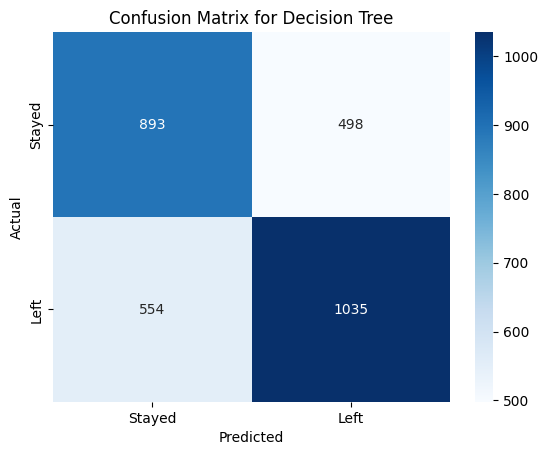


Random Forest Model Performance:
Accuracy: 0.73
Precision: 0.73
Recall: 0.73
F1-Score: 0.73
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71      1391
           1       0.75      0.73      0.74      1589

    accuracy                           0.73      2980
   macro avg       0.73      0.73      0.73      2980
weighted avg       0.73      0.73      0.73      2980



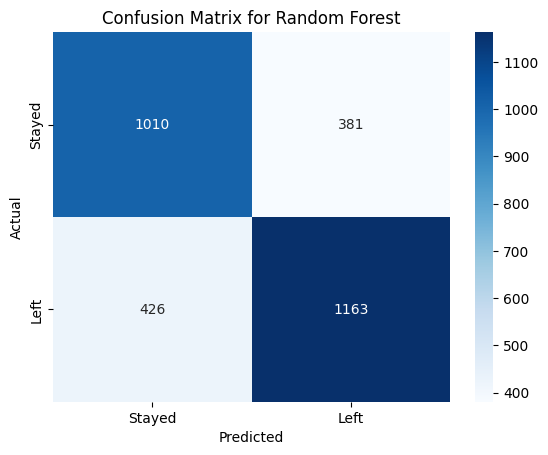


Support Vector Machine Model Performance:
Accuracy: 0.72
Precision: 0.72
Recall: 0.72
F1-Score: 0.72
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.72      0.70      1391
           1       0.75      0.71      0.73      1589

    accuracy                           0.72      2980
   macro avg       0.72      0.72      0.72      2980
weighted avg       0.72      0.72      0.72      2980



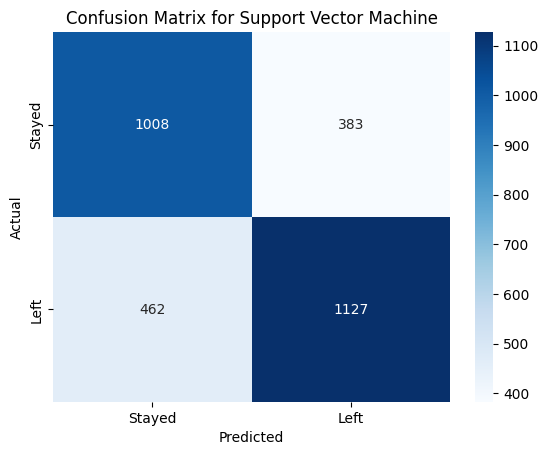


K-Nearest Neighbors Model Performance:
Accuracy: 0.65
Precision: 0.65
Recall: 0.65
F1-Score: 0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.64      0.63      1391
           1       0.67      0.65      0.66      1589

    accuracy                           0.65      2980
   macro avg       0.65      0.65      0.65      2980
weighted avg       0.65      0.65      0.65      2980



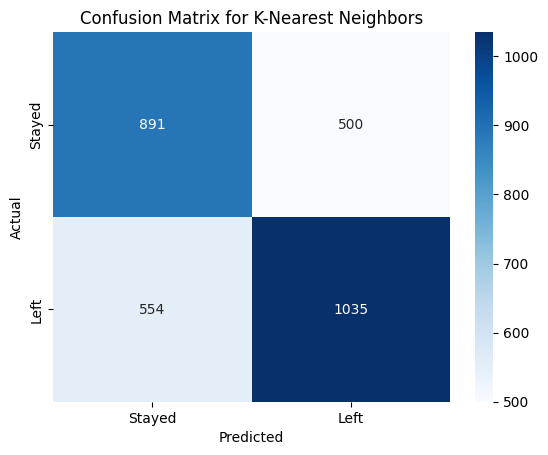


Best Model: Random Forest with Accuracy: 0.73

Overall Performance:
                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.709732   0.710225  0.709732  0.709901
1           Decision Tree  0.646980   0.648070  0.646980  0.647297
2           Random Forest  0.729195   0.729948  0.729195  0.729405
3  Support Vector Machine  0.716443   0.718051  0.716443  0.716744
4     K-Nearest Neighbors  0.646309   0.647354  0.646309  0.646619


<Figure size 1000x600 with 0 Axes>

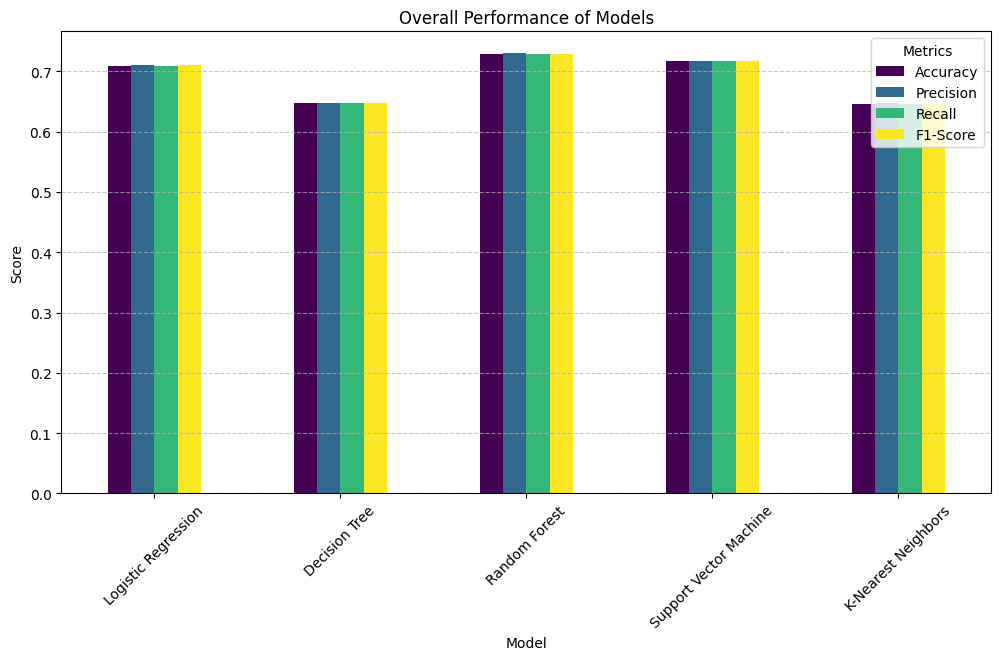

<ipython-input-2-aa4a815f03de>:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_df["Model"], y=overall_df["Accuracy"], palette="viridis")


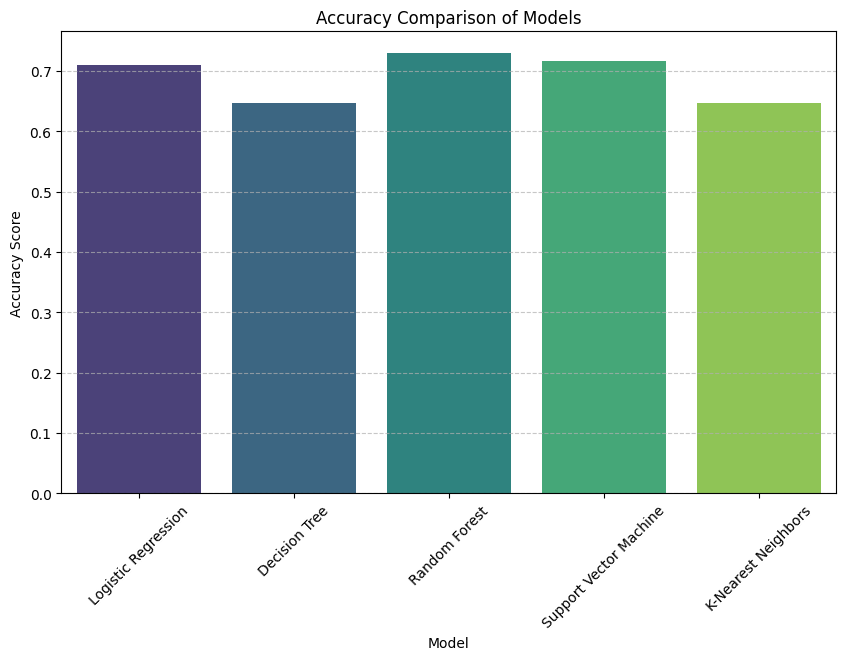

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("test.csv")

df.dropna(inplace=True)

if "Employee ID" in df.columns:
    df.drop(columns=["Employee ID"], inplace=True)

label_encoders = {}
for column in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

X = df.drop(columns=["Attrition"])
y = df["Attrition"]

scaler = StandardScaler()
X[X.select_dtypes(include=["int64", "float64"]).columns] = scaler.fit_transform(
    X[X.select_dtypes(include=["int64", "float64"]).columns]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

performance_results = {}
overall_metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    performance_results[name] = accuracy

    overall_metrics.append([name, accuracy, precision, recall, f1])

    print(f"\n{name} Model Performance:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

# Identify the best model
best_model = max(performance_results, key=performance_results.get)
print(f"\nBest Model: {best_model} with Accuracy: {performance_results[best_model]:.2f}")

overall_df = pd.DataFrame(overall_metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\nOverall Performance:")
print(overall_df)

plt.figure(figsize=(10, 6))
overall_df.set_index("Model").plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Overall Performance of Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=overall_df["Model"], y=overall_df["Accuracy"], palette="viridis")
plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
